# 03 ? Feature Extraction
Estrazione e distribuzione delle feature da ECG, accelerometro e dati clinici.

Dopo aver controllato qualit? e preprocessing dei segnali, trasformo le tracce continue in variabili numeriche che possano essere usate da un modello di machine learning. Questa fase ? centrale perch? le feature devono sintetizzare informazione fisiologicamente sensata senza perdere troppo del comportamento dinamico osservato nei test.

L'idea ? combinare tre livelli informativi: risposta cardiaca, intensit?/struttura del movimento e contesto clinico del paziente. In questo modo il dataset finale non descrive solo il segnale, ma anche il soggetto che lo ha generato.


In [1]:
# Inserisco la root del progetto nel path per richiamare le stesse funzioni usate nella pipeline completa.
import sys; sys.path.insert(0, '..')
# Tengo l'output pulito dai warning per concentrarmi sulla qualit? delle feature estratte.
import warnings; warnings.filterwarnings('ignore')
# Queste librerie servono per costruire tabelle, controllare distribuzioni e visualizzare differenze tra test.
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.data_loader import load_patient, get_test_segments, load_subject_info
from src.preprocessing import preprocess_ecg, preprocess_acc
from src.feature_extraction import extract_all_features
from src.visualization import plot_feature_boxplots
# Mantengo uno stile uniforme per leggere in modo coerente boxplot e tabelle riassuntive.
sns.set_theme(style='whitegrid')
%matplotlib inline


## 1. Feature per un singolo paziente

Prima di aggregare tutto il dataset controllo l'estrazione su un singolo paziente. ? un passaggio utile come sanity check: se le feature hanno senso a livello individuale, allora posso fidarmi di pi? dell'automazione sul dataset completo.


In [2]:
# Parto da un paziente esempio per validare passo passo la catena di estrazione delle feature.
data = load_patient('001', 1)
# Separo i due sensori perch? le feature verranno poi fuse ma nascono da sorgenti fisiologiche diverse.
ecg = data['ecg']; acc = data['acc']
# Preprocesso l'ECG cos? le feature cardiache siano calcolate su battiti rilevati in modo affidabile.
ecg_prep = preprocess_ecg(ecg['signal'], ecg['fs'])
# Preprocesso anche l'ACC per usare componenti e misure derivate pi? stabili del segnale grezzo.
acc_prep = preprocess_acc(acc['signal_x'], acc['signal_y'], acc['signal_z'], acc['fs'])
# Ricavo i segmenti dei test per estrarre feature coerenti con le varie condizioni del protocollo.
segments = get_test_segments(
    ecg['ann_samples'], ecg['ann_labels'],
    acc['ann_samples'], acc['ann_labels'],
    len(ecg['signal']), len(acc['signal_x']))
# Carico le informazioni cliniche perch? possono arricchire il profilo del paziente oltre ai soli biosignali.
subject_info = load_subject_info()
# Recupero la riga del soggetto se presente, cos? le feature finali includono anche il contesto clinico.
subject_row = subject_info.loc['001'] if '001' in subject_info.index else None
# Estraggo tutte le feature finestrate: questo ? il passaggio che traduce il segnale in input per il modello.
feat_df = extract_all_features('001', 1, ecg_prep, acc_prep, segments, subject_row)
# Controllo la shape per verificare quante finestre e quante variabili descrittive ottengo.
print('Shape:', feat_df.shape)
# Il conteggio per test mi aiuta a capire se il dataset del singolo soggetto ? bilanciato tra le varie prove.
print('Finestre per test:')
print(feat_df['test_label'].value_counts())
# Visualizzo le prime righe per controllare naming, unit? implicite e presenza di valori anomali.
feat_df.head()


Shape: (282, 66)
Finestre per test:
test_label
6MWT             81
GAIT_ANALYSIS    60
TUG              57
STAIR            51
VELO             33
Name: count, dtype: int64


,patient_id,session,test_label,window_start_ecg,window_end_ecg,ecg_mean_rr,ecg_sdnn,ecg_rmssd,ecg_pnn50,ecg_hr_mean,...,bmi,efs,days_post_surgery,surgery_type,nyha,has_af,has_copd,has_depression,ace_inhibitors,beta_blockers
0,001,1,GAIT_ANALYSIS,426789,430689,733.958724,13.757797,21.448994,0.000000,81.776649,...,26.297578,6.0,21.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0
1,001,1,GAIT_ANALYSIS,428739,432639,735.084428,13.657776,20.059087,0.000000,81.651056,...,26.297578,6.0,21.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0
2,001,1,GAIT_ANALYSIS,430689,434589,741.346155,26.856069,34.046381,7.692308,81.036843,...,26.297578,6.0,21.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0
3,001,1,GAIT_ANALYSIS,432639,436539,742.884621,31.301482,39.970398,15.384615,80.906211,...,26.297578,6.0,21.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0
4,001,1,GAIT_ANALYSIS,434589,438489,740.525333,20.570585,27.973990,7.500000,81.084626,...,26.297578,6.0,21.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0


## 2. Feature ECG ? distribuzione per test

Le feature ECG dovrebbero riflettere differenze tra condizioni di riposo, esercizio e recupero. Guardare la loro distribuzione per test mi aiuta a capire se la variabilit? estratta ? coerente con la fisiologia cardiaca attesa e se esistono feature potenzialmente discriminanti.


Feature ECG: ['ecg_mean_rr', 'ecg_sdnn', 'ecg_rmssd', 'ecg_pnn50', 'ecg_hr_mean', 'ecg_hr_min', 'ecg_hr_max', 'ecg_rr_range', 'ecg_cv_rr']


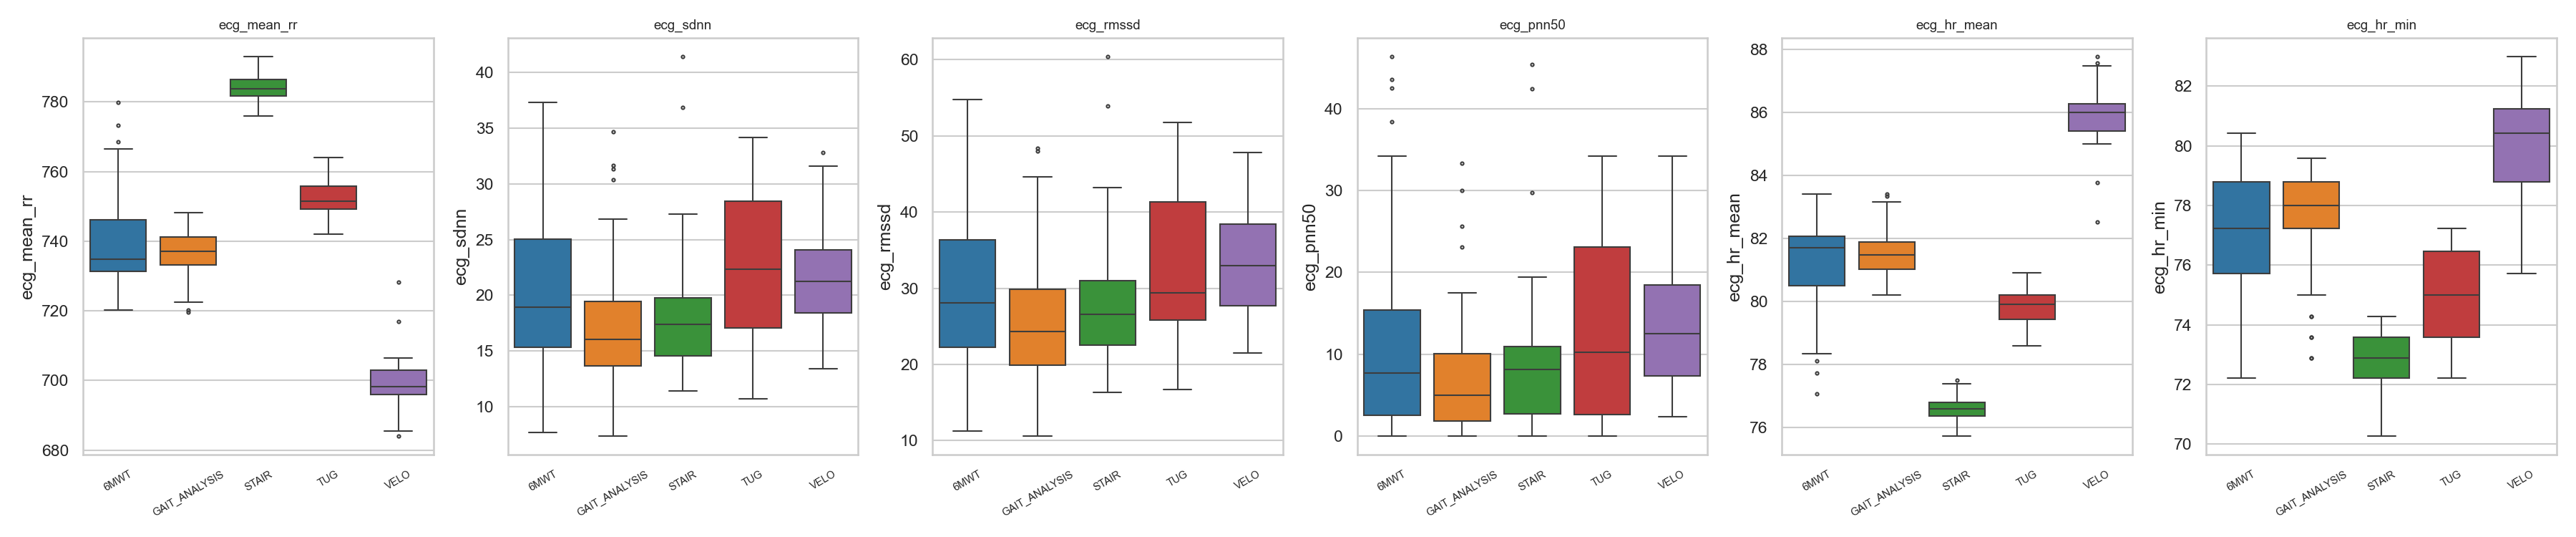

In [3]:
# Seleziono automaticamente le colonne ECG per evitare scelte manuali arbitrarie e mantenere il notebook scalabile.
ecg_cols = [c for c in feat_df.columns if c.startswith('ecg_')]
# Stampo i nomi per controllare quali descrittori cardiaci stanno entrando nel dataset finale.
print('Feature ECG:', ecg_cols)
# I boxplot per test mostrano se mediane e dispersioni cambiano in modo plausibile con il carico fisiologico.
plot_feature_boxplots(feat_df, ecg_cols, group_col='test_label',
    output_dir='../results/figures/boxplots')
from IPython.display import Image
# Ricarico un batch di boxplot per ispezionare rapidamente la separabilit? visiva delle feature cardiache.
Image('../results/figures/boxplots/boxplots_batch00.png')


## 3. Feature ACC ? distribuzione per test

Per l'accelerometro mi concentro su feature sintetiche di intensit?, energia, jerk e correlazione tra assi. Queste misure dovrebbero catturare sia quanto il paziente si muove sia come il movimento ? organizzato, aspetti molto rilevanti nella valutazione riabilitativa.


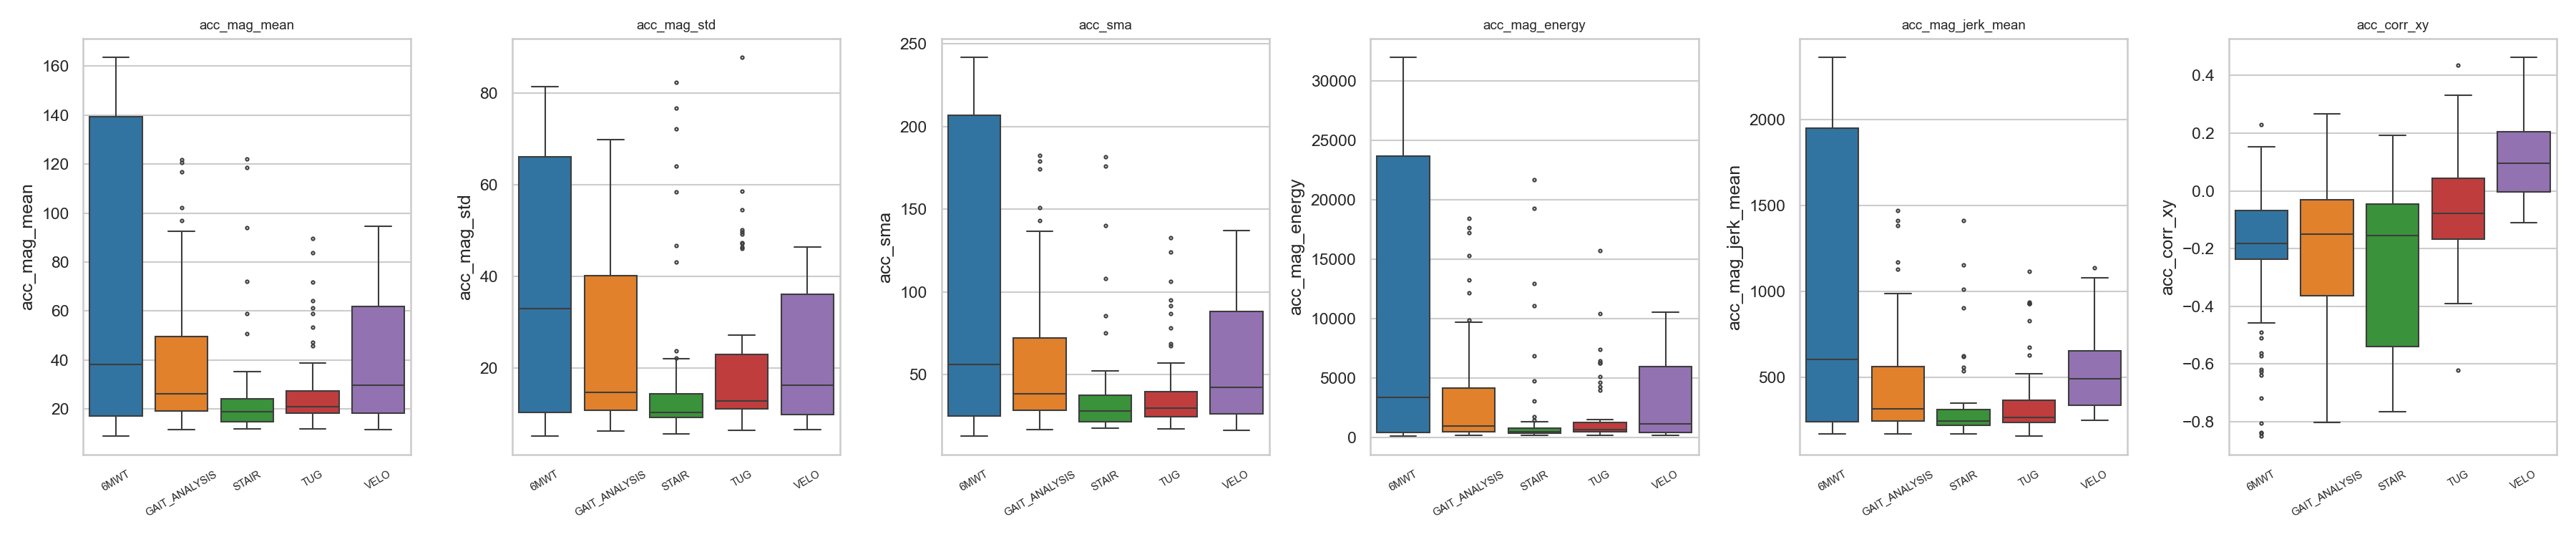

In [4]:
# Scelgo un sottoinsieme interpretabile di feature ACC per focalizzarmi sulle pi? leggibili dal punto di vista biomeccanico.
key_acc = ['acc_mag_mean', 'acc_mag_std', 'acc_sma', 'acc_mag_energy',
           'acc_mag_jerk_mean', 'acc_corr_xy', 'acc_corr_xz', 'acc_corr_yz']
# Anche qui il confronto per test serve a capire se il movimento durante le prove lascia firme statistiche distinte.
plot_feature_boxplots(feat_df, key_acc, group_col='test_label',
    output_dir='../results/figures/boxplots_acc')
# Visualizzo il primo gruppo di grafici per valutare rapidamente intensit? e coordinazione del movimento tra test diversi.
Image('../results/figures/boxplots_acc/boxplots_batch00.png')


## 4. Dataset completo ? tutti i pazienti

Dopo la validazione sul singolo caso estendo la procedura a tutti i pazienti e a tutte le sessioni disponibili. Questo passaggio costruisce il dataset finale per il machine learning e richiede robustezza, perch? in pratica reale possono esserci registrazioni incomplete, errori o prove mancanti.


In [5]:
from src.data_loader import list_patients, get_patient_sessions
# Inizializzo una lista di DataFrame perch? ogni paziente/sessione produce un blocco di feature separato.
all_dfs = []
# Scorro tutti i pazienti per costruire un dataset che rappresenti l'intera coorte disponibile.
for pid in list_patients():
    # Per ogni soggetto considero tutte le sessioni per non perdere informazione longitudinale utile.
    for sess in get_patient_sessions(pid):
        try:
            # Carico i dati grezzi della sessione corrente prima di applicare l'intera pipeline.
            d = load_patient(pid, sess)
            e = d['ecg']; a = d['acc']
            # Ripeto il preprocessing ECG per garantire uniformit? delle feature tra tutti i soggetti.
            ep = preprocess_ecg(e['signal'], e['fs'])
            # Faccio lo stesso per l'ACC, cos? il confronto tra sessioni avviene su segnali trattati allo stesso modo.
            ap = preprocess_acc(a['signal_x'], a['signal_y'], a['signal_z'], a['fs'])
            # Ricostruisco i segmenti del protocollo, indispensabili per assegnare a ogni finestra il test corretto.
            segs = get_test_segments(e['ann_samples'], e['ann_labels'],
                a['ann_samples'], a['ann_labels'],
                len(e['signal']), len(a['signal_x']))
            # Associo anche il contesto clinico del soggetto quando disponibile.
            srow = subject_info.loc[pid] if pid in subject_info.index else None
            # Estraggo le feature finali della sessione corrente.
            df_ = extract_all_features(pid, sess, ep, ap, segs, srow)
            # Aggiungo solo DataFrame non vuoti per evitare di inquinare il dataset con sessioni inutilizzabili.
            if len(df_) > 0: all_dfs.append(df_)
        except Exception as ex:
            # In una pipeline su dati clinici reali preferisco loggare e proseguire, cos? un caso anomalo non blocca tutto.
            print(f'Skip {pid}_{sess}: {ex}')
# Concateno tutte le finestre in un unico dataset pronto per analisi successive o training.
full_df = pd.concat(all_dfs, ignore_index=True)
# La shape finale quantifica la dimensione reale del materiale disponibile per il machine learning.
print('Dataset completo shape:', full_df.shape)
print('Finestre per test:')
# Il bilanciamento per test ? un controllo importante perch? classi troppo sbilanciate possono falsare il modello.
print(full_df['test_label'].value_counts())
# Esporto il dataset tabellare per riutilizzarlo nelle fasi di modellazione senza ripetere tutta la pipeline.
full_df.to_csv('../results/tables/features_all.csv', index=False)
print('Salvato in results/tables/features_all.csv')


Dataset completo shape: (35717, 66)
Finestre per test:
test_label
6MWT             13383
GAIT_ANALYSIS    10011
STAIR             5375
TUG               3802
VELO              3146
Name: count, dtype: int64
Salvato in results/tables/features_all.csv
